In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/067_urmia/results/profiles/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 9)


,PNT1,PNT2,PNT3,PT251,PT252,PT253,PT501,PT502,PT503
ENSG00000000003.15,60.010164,56.864285,67.530799,42.741514,53.950983,38.825483,28.545982,31.894017,27.811313
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.079146,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,74.269017,70.981144,80.958673,68.736836,71.528195,76.100282,70.167383,77.002498,74.407704
ENSG00000000457.14,8.006860,8.168558,8.666231,9.626468,9.814037,6.308987,7.687010,7.633767,8.561684
ENSG00000000460.17,2.532638,2.156166,4.032114,2.843206,3.701280,2.306823,2.328512,2.455071,2.896012
...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,3.037490,2.813491,2.286681,2.380306,2.019163,2.365784,2.512866,2.189668,2.195346
ENSG00000291300.1,0.488906,0.294105,1.026266,0.787008,0.364076,0.687859,0.967987,0.305009,0.698456


In [6]:
for element in expression.columns:
    print(element)

PNT1
PNT2
PNT3
PT251
PT252
PT253
PT501
PT502
PT503


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(14265, 9)
(1719, 9)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.3717837  0.21449474]


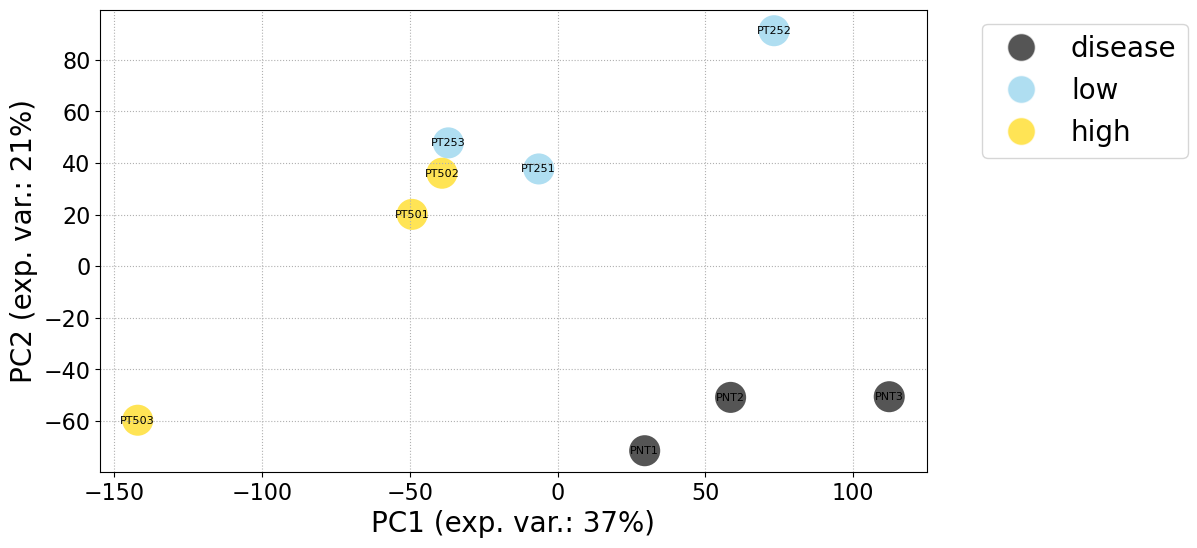

In [10]:
for i in range(len(new)):

    name = expression.columns[i]

    # colors
    if 'PN' in name:
        the_color = 'black'
    elif 'PT25' in name:
        the_color = 'skyblue'
    elif 'PT50' in name:
        the_color = 'gold'
    else:
        print('error')

        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=500, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3)
]

matplotlib.pyplot.legend(legend_elements, ['disease', 'low', 'high'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.45745373 0.24997717]


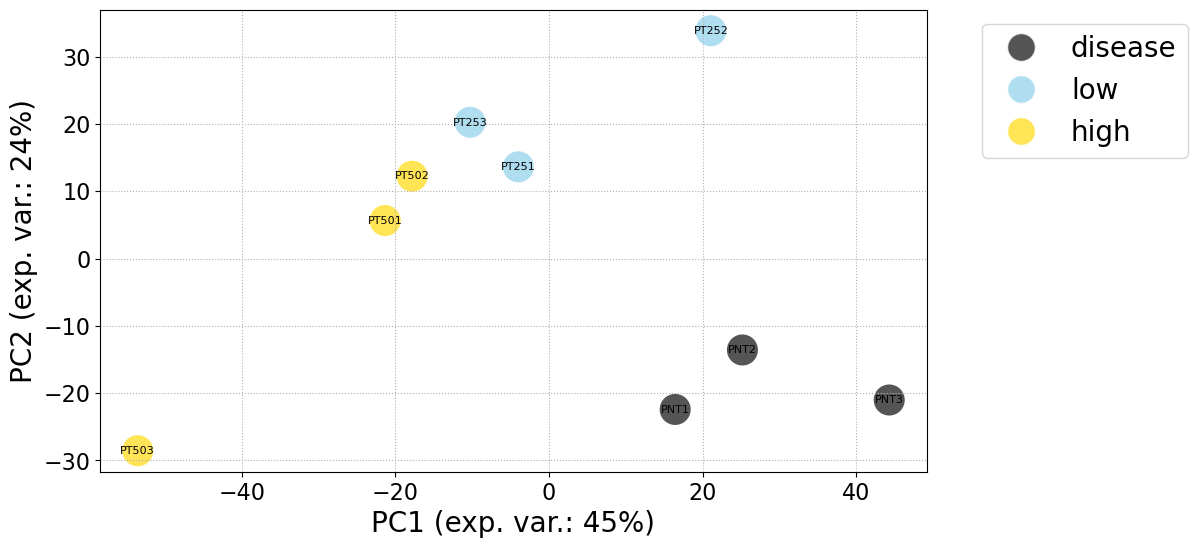

In [12]:
for i in range(len(new)):

    name = expression.columns[i]

    # colors
    if 'PN' in name:
        the_color = 'black'
    elif 'PT25' in name:
        the_color = 'skyblue'
    elif 'PT50' in name:
        the_color = 'gold'
    else:
        print('error')

        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=500, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3)
]

matplotlib.pyplot.legend(legend_elements, ['disease', 'low', 'high'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

In [13]:
# 5. distributions

In [14]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,PNT1,PNT2,PNT3,PT251,PT252,PT253,PT501,PT502,PT503
ENSG00000000003.15,5.930978,5.854601,6.098681,5.450931,5.780073,5.315620,4.884890,5.039753,4.848564
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.109890,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,6.233984,6.169547,6.356825,6.123849,6.180470,6.268664,6.153144,6.285448,6.236640
ENSG00000000457.14,3.171024,3.196695,3.272953,3.409590,3.434833,2.869671,3.118860,3.109990,3.257265
ENSG00000000460.17,1.820746,1.658173,2.331165,1.942310,2.233054,1.725446,1.734877,1.788715,1.961998


148
14.782160532409174


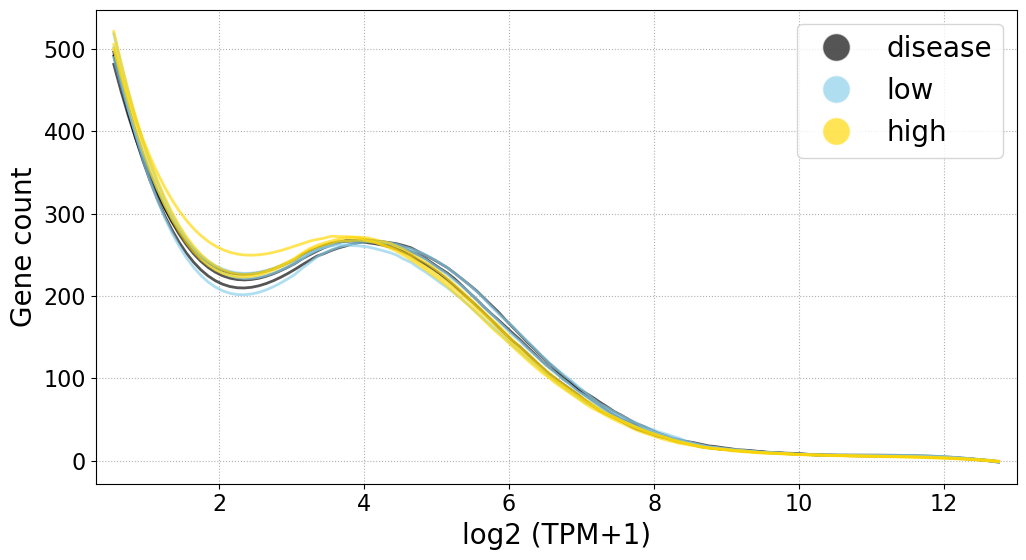

In [15]:
found_max = 14.8
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    name = working_samples[i]

    ## colors
    if 'PN' in name:
        the_color = 'black'
    elif 'PT25' in name:
        the_color = 'skyblue'
    elif 'PT50' in name:
        the_color = 'gold'
    else:
        print('error')
    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
#matplotlib.pyplot.ylim([0, 400])

legend_elements = [
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3)
]

matplotlib.pyplot.legend(legend_elements, ['disease', 'low', 'high'], ncol=1, loc='upper right')

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)